In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
# MNIST Handwritten Digit Classification using CNN

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os

# Ensure results directory exists
os.makedirs("../results", exist_ok=True)

In [4]:
# Step 1: Load dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
print("✅ MNIST dataset loaded successfully!")


✅ MNIST dataset loaded successfully!


In [5]:
# Step 2: Normalize and reshape
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)


In [6]:
# Step 3: Build CNN model
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

c:\Users\Administrator\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Step 4: Train model
history = model.fit(X_train, y_train, epochs=5, batch_size=64,
                    validation_split=0.1, verbose=2)


Epoch 1/5
844/844 - 34s - 40ms/step - accuracy: 0.9340 - loss: 0.2131 - val_accuracy: 0.9827 - val_loss: 0.0576
Epoch 2/5
844/844 - 29s - 34ms/step - accuracy: 0.9809 - loss: 0.0645 - val_accuracy: 0.9907 - val_loss: 0.0340
Epoch 3/5
844/844 - 27s - 32ms/step - accuracy: 0.9859 - loss: 0.0461 - val_accuracy: 0.9887 - val_loss: 0.0395
Epoch 4/5
844/844 - 32s - 38ms/step - accuracy: 0.9881 - loss: 0.0374 - val_accuracy: 0.9888 - val_loss: 0.0402
Epoch 5/5
844/844 - 25s - 29ms/step - accuracy: 0.9906 - loss: 0.0291 - val_accuracy: 0.9923 - val_loss: 0.0315


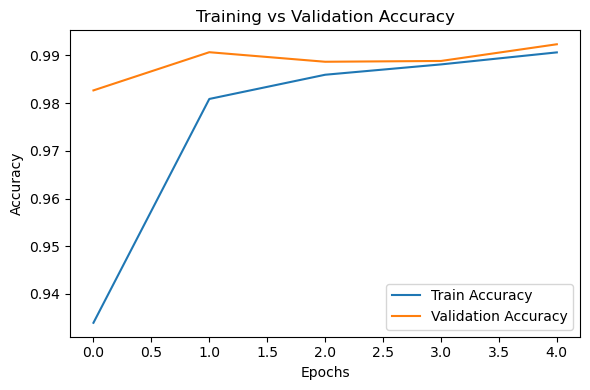

In [8]:
# Step 6: Plot accuracy curve
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig("../results/mnist_accuracy_graph.png")
plt.show()

In [9]:
# Step 7: Predict sample images
predictions = model.predict(X_test[:5])
predicted_labels = np.argmax(predictions, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step


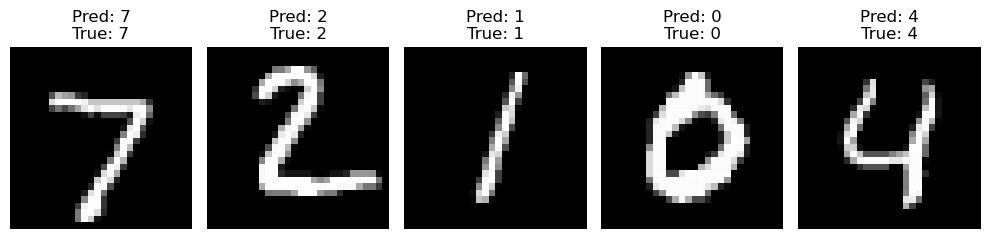

In [10]:
# Step 8: Visualize predictions
plt.figure(figsize=(10,3))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {y_test[i]}")
    plt.axis('off')
plt.tight_layout()
plt.savefig("../results/mnist_sample_predictions.png")
plt.show()

In [11]:
# Step 9: Save model for Streamlit
model.save("../results/mnist_cnn_model.h5")
print("✅ Model saved successfully!")


✅ Model saved successfully!
